<a href="https://colab.research.google.com/github/lorida0777/Recommendation_services_hospitaliers/blob/main/Recommendation_services_hospitaliers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installations & Imports

In [13]:
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn nltk spacy tqdm
!python -m spacy download fr_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 26.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [14]:
import os, re, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import nltk
import spacy
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, EarlyStoppingCallback)
from datasets import Dataset as HFDataset

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device : {DEVICE}")

✅ Device : cpu


Génération du Dataset

In [15]:
SERVICES = ["Cardiologie","Urgences","Pédiatrie","Oncologie","Orthopédie","Neurologie"]

templates = {
    "Cardiologie": [
        "Hospitalisé pour douleurs thoraciques et arythmie cardiaque. ECG et bilan sanguin rapides. Le cardiologue a expliqué clairement mon traitement.",
        "Prise en charge excellente suite à mon infarctus. Pose d'un stent en urgence. Personnel compétent et rassurant.",
        "Suivi pour insuffisance cardiaque chronique. Échographies et holters bien organisés. Cardiologue à l'écoute.",
        "Consultation pour hypertension artérielle sévère. Ajustement du traitement antihypertenseur fait avec soin.",
        "Hospitalisation pour fibrillation auriculaire. Cardioversion réalisée dans de bonnes conditions.",
        "Mon père opéré du cœur ici. Équipe chirurgicale et cardiologues remarquables tout au long de la procédure.",
        "Douleurs poitrine et essoufflement : angine de poitrine diagnostiquée. Traitement bien expliqué.",
        "Pose d'un pacemaker. Tout s'est très bien déroulé, infirmières attentionnées, médecin professionnel.",
        "Suivi post chirurgie valvulaire. Rendez-vous de contrôle bien espacés, examens cardiaques coordonnés.",
        "Épreuve d'effort et coronarographie pour bilan de douleurs thoraciques. Résultats expliqués avec pédagogie.",
    ],
    "Urgences": [
        "Accueil aux urgences pour coupure profonde à la main. Attente 2h. Plaie suturée correctement.",
        "Arrivé en ambulance suite à une chute. Urgentistes réactifs pour écarter toute fracture. Scanner et radio bien réalisés.",
        "Nuit aux urgences pour forte fièvre et frissons. Soignants débordés mais prise en charge correcte.",
        "Mon enfant a avalé un corps étranger. Prise en charge immédiate. Personnel très professionnel.",
        "Intoxication alimentaire avec déshydratation. Perfusion posée rapidement. Hospitalisation courte.",
        "Accident de voiture, fracture suspectée. Immobilisation et douleur bien gérées en attendant l'orthopédiste.",
        "Crise d'asthme sévère aux urgences. Nébulisation et corticoïdes administrés rapidement.",
        "Douleur abdominale intense. Bilan et échographie en urgence. Appendicite diagnostiquée et opérée.",
        "Service très chargé mais triage efficace. Mon cas prioritaire traité sans délai excessif.",
        "Malaise avec perte de connaissance. Bilan complet réalisé avant orientation vers le bon service.",
    ],
    "Pédiatrie": [
        "Mon fils de 4 ans hospitalisé pour bronchiolite sévère. Équipe pédiatrique formidable, douce et rassurante.",
        "Ma fille traitée pour otite à répétition. Pose de drains sous anesthésie légère. Tout s'est bien passé.",
        "Hospitalisation pour déshydratation d'un nourrisson de 6 mois. Équipe rapide, parents au chevet.",
        "Suivi de croissance pour enfant avec retard psychomoteur. Service équipé, médecins à l'écoute.",
        "Convulsion fébrile de mon enfant. Prise en charge rapide et explications très claires.",
        "Service de néonatologie exceptionnel pour notre prématuré de 32 semaines. Équipe soignante remarquable.",
        "Gastroentérite avec vomissements chez mon bébé. Réhydratation orale bien supervisée.",
        "Allergie alimentaire sévère chez mon fils. Tests allergologiques réalisés en pédiatrie.",
        "Suivi oncologique pédiatrique pour leucémie. Équipe remarquable humainement.",
        "Pneumonie bilatérale chez une enfant de 7 ans. Antibiothérapie efficace, sortie après 5 jours.",
    ],
    "Oncologie": [
        "Suivi en oncologie pour cancer du sein. Chimiothérapie bien tolérée grâce à l'accompagnement.",
        "Immunothérapie pour mélanome métastatique. Suivi biologique et clinique rigoureux.",
        "Radiothérapie conformationnelle pour cancer de la prostate. Service bien organisé.",
        "Cancer colorectal avec métastases hépatiques. Protocole FOLFOX proposé par le staff pluridisciplinaire.",
        "Cure de chimiothérapie. Équipe infirmière professionnelle et bienveillante.",
        "Suivi post-chirurgical cancer pulmonaire. Scanners bien planifiés, résultats expliqués avec clarté.",
        "Consultation d'oncogénétique. Test BRCA réalisé. Suivi adapté à mon profil de risque.",
        "Lymphome hodgkinien traité par ABVD. Rémission obtenue après 6 cures.",
        "Greffe de moelle osseuse réalisée ici. Équipe de soins intensifs hématologiques au top.",
        "Essai clinique pour cancer du rein réfractaire. Reconnaissant envers l'équipe oncologique.",
    ],
    "Orthopédie": [
        "Opération du ménisque suite à blessure sportive. Chirurgie arthroscopique réussie. Rééducation en cours.",
        "Pose d'une prothèse totale de hanche. Récupération fonctionnelle rapide grâce à la kinésithérapie.",
        "Fracture du poignet traitée chirurgicalement avec pose d'une plaque. Excellent travail.",
        "Lombalgie chronique. IRM réalisée, hernie discale diagnostiquée, infiltration proposée.",
        "Chirurgie du canal carpien sous anesthésie locale. Fourmillements disparus dès le lendemain.",
        "Remplacement de prothèse de genou après descellement. Kinésithérapie débutée rapidement.",
        "Fracture complexe de la cheville avec ligaments. Ostéosynthèse réalisée. Suivi radiologique rigoureux.",
        "Scoliose sévère opérée par arthrodèse vertébrale. Résultat remarquable sur douleur et posture.",
        "Rupture du tendon d'Achille. Chirurgie réparatrice suivie d'une rééducation intensive.",
        "Douleurs d'épaule chroniques. Échographie et bilan articulaire complet. Infiltration proposée.",
    ],
    "Neurologie": [
        "Hospitalisation pour AVC ischémique. Thrombolyse réalisée dans les délais. Récupération en bonne voie.",
        "Suivi pour épilepsie pharmaco-résistante. EEG vidéo réalisé. Traitement antiépileptique ajusté.",
        "Consultation pour migraines chroniques invalidantes. Traitement de fond efficace trouvé.",
        "Diagnostic de sclérose en plaques. Équipe neurologique exemplaire dans l'annonce et le suivi.",
        "Bilan de démence débutante. Neuropsychologue, IRM, PET scan : bilan exhaustif bien expliqué.",
        "Maladie de Parkinson suivie ici. Neurologue ajuste le traitement régulièrement.",
        "Névralgie du trijumeau. Radiochirurgie stéréotaxique efficace. Douleurs réduites de 80%.",
        "EMG et étude de conduction nerveuse pour polyneuropathie diabétique. Résultats bien expliqués.",
        "Méningite bactérienne prise en charge en urgence. Antibiothérapie immédiate. Séquelles limitées.",
        "Suivi post-AVC avec rééducation. Équipe pluridisciplinaire kiné, ortho, orthophoniste coordonnée.",
    ]
}

prefixes = ["","Très satisfait : ","Dans l'ensemble, ","Suite à mon hospitalisation, ","Je témoigne : ",""]
suffixes = ["","Je recommande vivement."," Service de qualité."," Personnel dévoué.",""]

def generate_dataset(n_per_class=300):
    data = []
    for service, texts in templates.items():
        count = 0
        while count < n_per_class:
            avis = random.choice(prefixes) + random.choice(texts) + random.choice(suffixes)
            data.append({"texte": avis.strip(), "service": service})
            count += 1
    return pd.DataFrame(data).sample(frac=1, random_state=SEED).reset_index(drop=True)

df = generate_dataset(n_per_class=300)
print(f"✅ Dataset : {len(df)} avis")
print(df['service'].value_counts())
df.head()

✅ Dataset : 1800 avis
service
Neurologie     300
Oncologie      300
Pédiatrie      300
Cardiologie    300
Orthopédie     300
Urgences       300
Name: count, dtype: int64


,texte,service
0,Je témoigne : Hospitalisation pour AVC ischémi...,Neurologie
1,Suivi post-chirurgical cancer pulmonaire. Scan...,Oncologie
2,Gastroentérite avec vomissements chez mon bébé...,Pédiatrie
3,Très satisfait : Hospitalisation pour fibrilla...,Cardiologie
4,"Dans l'ensemble, Douleurs d'épaule chroniques....",Orthopédie


EDA

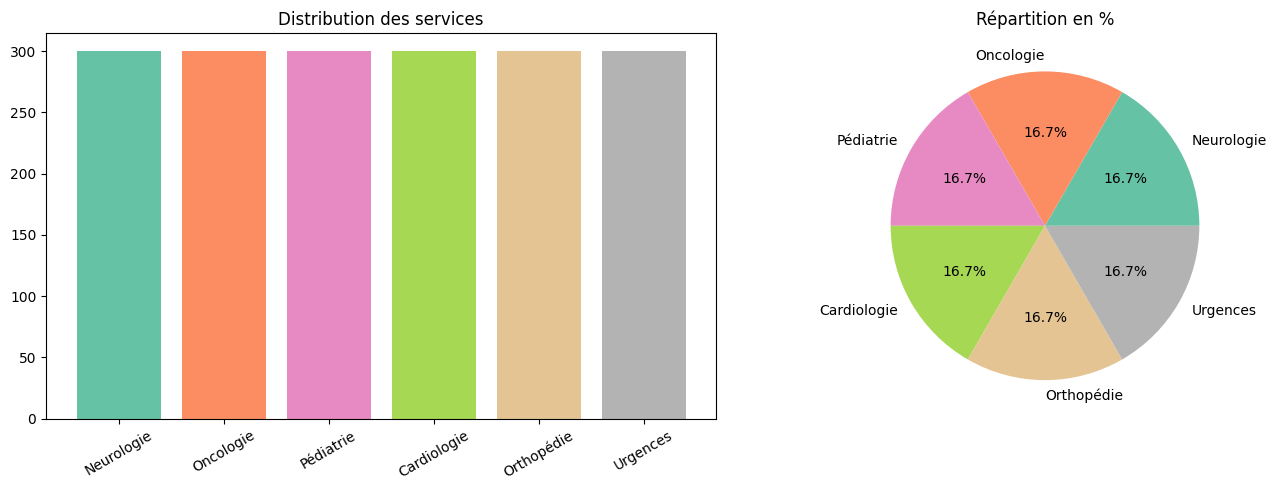

           nb_mots
count  1800.000000
mean     15.488333
std       2.997289
min       8.000000
25%      13.000000
50%      15.000000
75%      17.000000
max      26.000000


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df['service'].value_counts()
axes[0].bar(counts.index, counts.values, color=plt.cm.Set2(np.linspace(0,1,len(counts))))
axes[0].set_title('Distribution des services')
axes[0].tick_params(axis='x', rotation=30)
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=plt.cm.Set2(np.linspace(0,1,len(counts))))
axes[1].set_title('Répartition en %')
plt.tight_layout(); plt.show()

df['nb_mots'] = df['texte'].apply(lambda x: len(x.split()))
print(df[['nb_mots']].describe())

Préprocessing NLP

In [17]:
try:
    nlp = spacy.load('fr_core_news_sm')
    SPACY_AVAILABLE = True
except:
    SPACY_AVAILABLE = False

STOP_WORDS_FR = set(stopwords.words('french'))
STOP_WORDS_FR -= {'pas','non','très','bien','mal','sans','plus','moins'}
stemmer = SnowballStemmer('french')

def nettoyer_texte(texte):
    texte = texte.lower()
    texte = re.sub(r'[\n\r\t]', ' ', texte)
    texte = re.sub(r'[^a-zàâäéèêëîïôùûüç\s]', ' ', texte)
    texte = re.sub(r'\s+', ' ', texte).strip()
    return texte

def supprimer_stopwords(texte):
    tokens = word_tokenize(texte, language='french')
    return ' '.join([t for t in tokens if t not in STOP_WORDS_FR and len(t) > 2])

def lemmatiser(texte):
    if not SPACY_AVAILABLE:
        return ' '.join([stemmer.stem(t) for t in texte.split()])
    doc = nlp(texte)
    return ' '.join([t.lemma_ for t in doc if not t.is_stop and len(t.text) > 2])

def pipeline_preprocessing(texte):
    return lemmatiser(supprimer_stopwords(nettoyer_texte(texte)))

print("⏳ Preprocessing...")
df['texte_clean'] = df['texte'].apply(pipeline_preprocessing)
print("✅ Terminé !")
print("\nAVANT :", df['texte'].iloc[0][:100])
print("APRÈS :", df['texte_clean'].iloc[0][:100])

⏳ Preprocessing...
✅ Terminé !

AVANT : Je témoigne : Hospitalisation pour AVC ischémique. Thrombolyse réalisée dans les délais. Récupératio
APRÈS : témoigner hospitalisation avc ischémique thrombolyse réaliser délai récupération bon voie service qu


Encodage & Split

In [18]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['service'])
NUM_CLASSES = len(le.classes_)
LABEL_NAMES = list(le.classes_)
print(f"✅ {NUM_CLASSES} classes : {LABEL_NAMES}")

X = df['texte_clean'].values
X_raw = df['texte'].values
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

X_train_raw, X_temp_raw, _, _ = train_test_split(X_raw, y, test_size=0.30, random_state=SEED, stratify=y)
X_val_raw, X_test_raw, _, _ = train_test_split(X_temp_raw, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

✅ 6 classes : ['Cardiologie', 'Neurologie', 'Oncologie', 'Orthopédie', 'Pédiatrie', 'Urgences']
Train: 1260 | Val: 270 | Test: 270


Fonctions d'évaluation

In [19]:
def evaluer_modele(y_true, y_pred, nom, label_names):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')

    print(f"\n{'='*55}\n  📊 {nom}\n{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=label_names))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for idx, (norm, label) in enumerate([(None,'Brute'),('true','Normalisée')]):
        cm = confusion_matrix(y_true, y_pred, normalize=norm)
        ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=axes[idx], cmap='Blues', colorbar=False)
        axes[idx].set_title(f'{nom} — {label}')
        axes[idx].tick_params(axis='x', rotation=30)
    plt.tight_layout(); plt.show()

    return {'modele': nom, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

resultats = []

Modèle 1 : TF-IDF + Logistic Regression

✅ Baseline entraîné en 0.20s

  📊 TF-IDF + Logistic Regression
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000
              precision    recall  f1-score   support

 Cardiologie       1.00      1.00      1.00        45
  Neurologie       1.00      1.00      1.00        45
   Oncologie       1.00      1.00      1.00        45
  Orthopédie       1.00      1.00      1.00        45
   Pédiatrie       1.00      1.00      1.00        45
    Urgences       1.00      1.00      1.00        45

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270



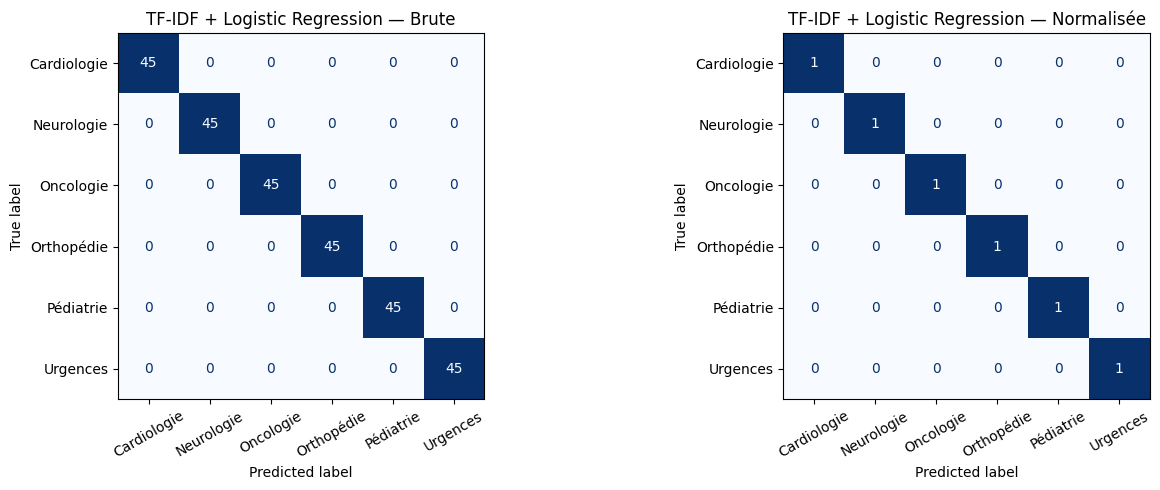

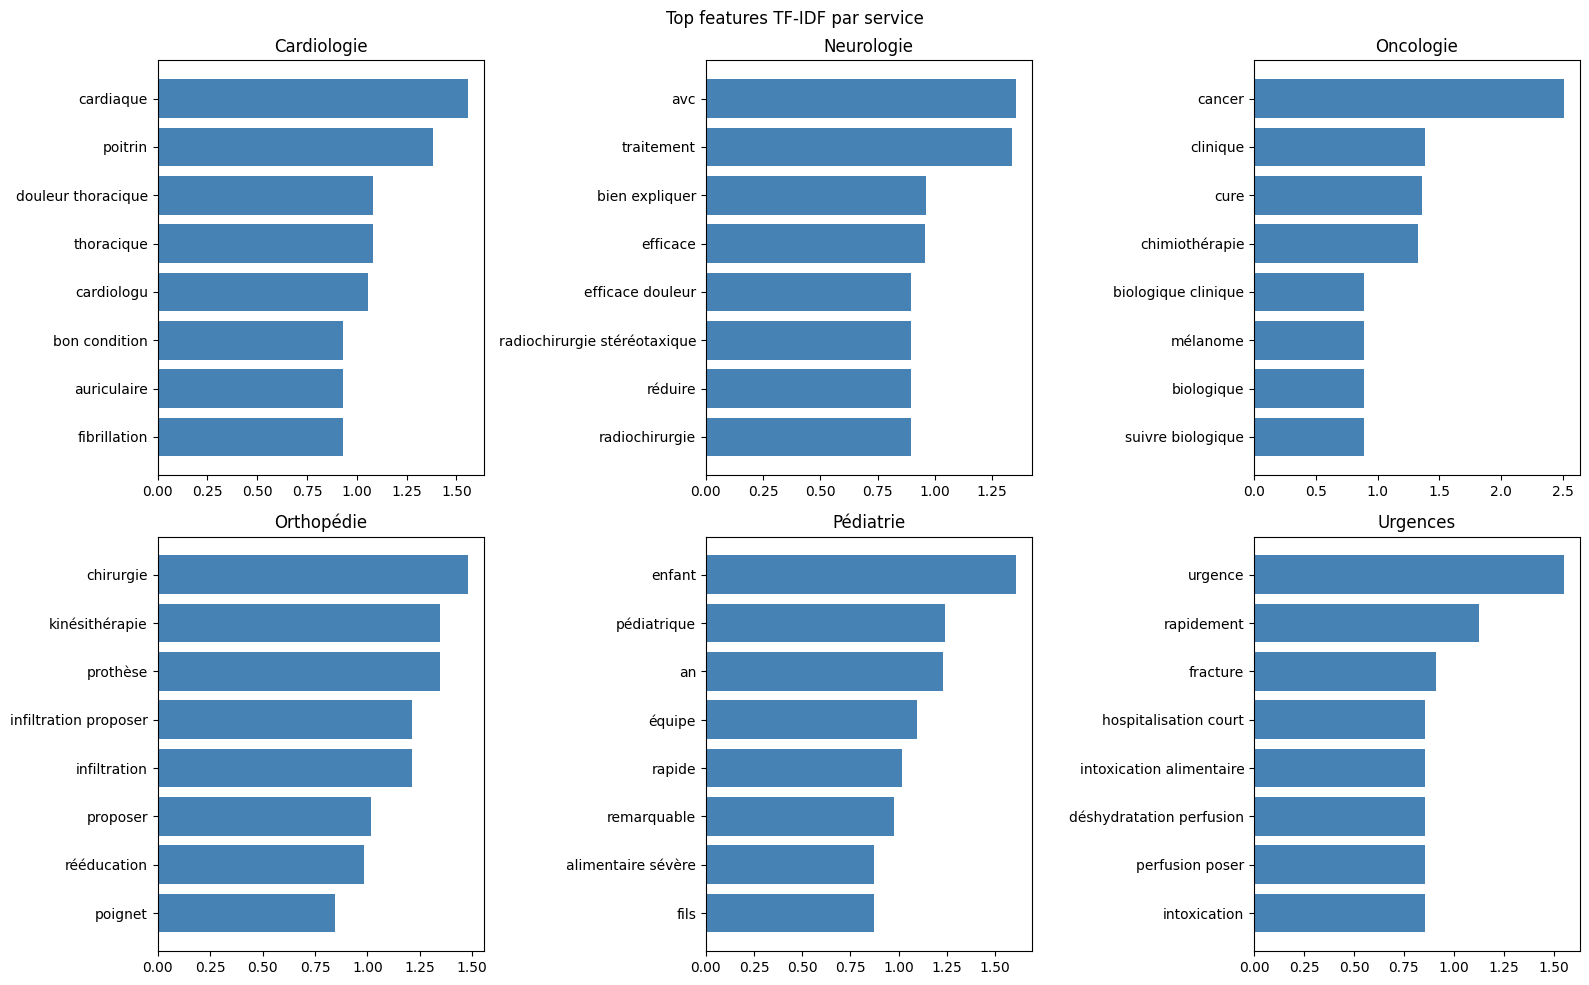

In [20]:
t0 = time.time()

pipeline_baseline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=15000, ngram_range=(1,2),
        min_df=2, max_df=0.95, sublinear_tf=True
    )),
    ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=SEED,
                                multi_class='multinomial', solver='lbfgs'))
])
pipeline_baseline.fit(X_train, y_train)
temps = time.time() - t0

y_pred_base = pipeline_baseline.predict(X_test)
print(f"✅ Baseline entraîné en {temps:.2f}s")

res = evaluer_modele(y_test, y_pred_base, "TF-IDF + Logistic Regression", LABEL_NAMES)
res['temps'] = round(temps, 2)
resultats.append(res)

# Top features par classe
vectorizer = pipeline_baseline.named_steps['tfidf']
clf = pipeline_baseline.named_steps['clf']
feature_names = vectorizer.get_feature_names_out()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, (ax, name) in enumerate(zip(axes.flatten(), LABEL_NAMES)):
    coef = clf.coef_[i]
    top_idx = np.argsort(coef)[-8:]
    ax.barh([feature_names[j] for j in top_idx], [coef[j] for j in top_idx], color='steelblue')
    ax.set_title(f'{name}')
plt.suptitle('Top features TF-IDF par service')
plt.tight_layout(); plt.show()

Modèle 2 : BiLSTM

✅ Vocabulaire : 369 tokens
✅ Paramètres BiLSTM : 708,230
Epoch  1 | Train: 1.5041 | Val: 0.5458 | Acc: 0.9185
Epoch  2 | Train: 0.1550 | Val: 0.0108 | Acc: 1.0000
Epoch  3 | Train: 0.0117 | Val: 0.0034 | Acc: 1.0000
Epoch  4 | Train: 0.0065 | Val: 0.0028 | Acc: 1.0000
Epoch  5 | Train: 0.0044 | Val: 0.0016 | Acc: 1.0000
Epoch  6 | Train: 0.0039 | Val: 0.0014 | Acc: 1.0000
Epoch  7 | Train: 0.0028 | Val: 0.0011 | Acc: 1.0000
Epoch  8 | Train: 0.0021 | Val: 0.0009 | Acc: 1.0000
Epoch  9 | Train: 0.0028 | Val: 0.0010 | Acc: 1.0000
Epoch 10 | Train: 0.0043 | Val: 0.0007 | Acc: 1.0000
Epoch 11 | Train: 0.0188 | Val: 0.0033 | Acc: 1.0000
Epoch 12 | Train: 0.0098 | Val: 0.0009 | Acc: 1.0000
Epoch 13 | Train: 0.0075 | Val: 0.0009 | Acc: 1.0000
Epoch 14 | Train: 0.0038 | Val: 0.0006 | Acc: 1.0000
Epoch 15 | Train: 0.0014 | Val: 0.0005 | Acc: 1.0000
Epoch 16 | Train: 0.0012 | Val: 0.0004 | Acc: 1.0000
Epoch 17 | Train: 0.0011 | Val: 0.0004 | Acc: 1.0000
Epoch 18 | Train: 0.0009 | Val: 0.0004 | A

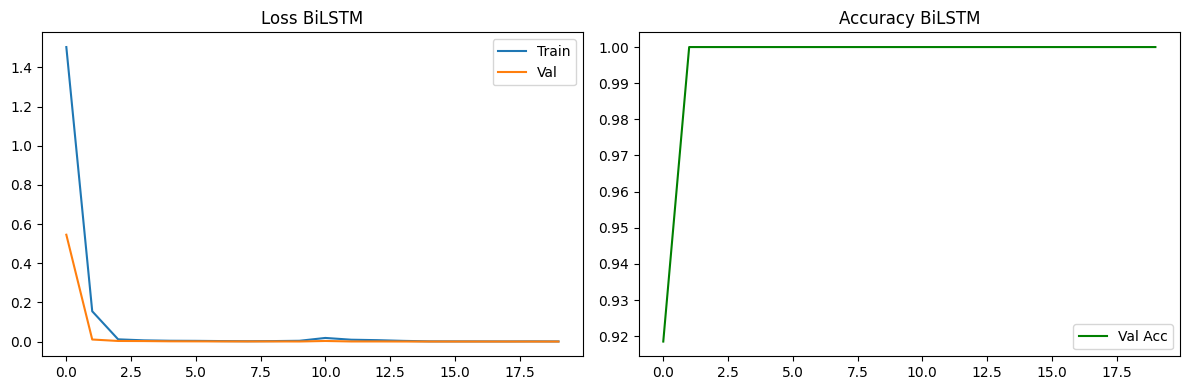


  📊 BiLSTM Deep Learning
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000
              precision    recall  f1-score   support

 Cardiologie       1.00      1.00      1.00        45
  Neurologie       1.00      1.00      1.00        45
   Oncologie       1.00      1.00      1.00        45
  Orthopédie       1.00      1.00      1.00        45
   Pédiatrie       1.00      1.00      1.00        45
    Urgences       1.00      1.00      1.00        45

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270



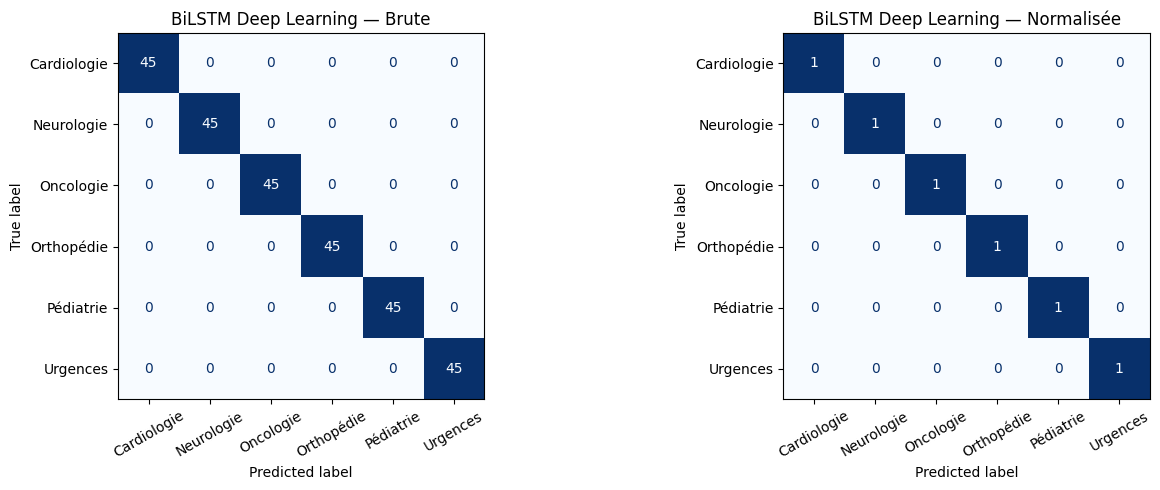

In [21]:
MAX_VOCAB, MAX_LEN, EMBED_DIM, HIDDEN_DIM = 10000, 80, 128, 128

from collections import Counter

class Vocabulaire:
    def __init__(self, max_vocab=10000):
        self.token2idx = {'<PAD>': 0, '<UNK>': 1}
    def construire(self, corpus):
        compteur = Counter()
        for t in corpus: compteur.update(t.split())
        for token, _ in compteur.most_common(MAX_VOCAB - 2):
            self.token2idx[token] = len(self.token2idx)
        print(f"✅ Vocabulaire : {len(self.token2idx)} tokens")
    def encoder(self, texte, max_len):
        idx = [self.token2idx.get(t, 1) for t in texte.split()[:max_len]]
        return idx + [0] * (max_len - len(idx))

vocab = Vocabulaire()
vocab.construire(X_train)
VOCAB_SIZE = len(vocab.token2idx)

class DatasetAvis(Dataset):
    def __init__(self, textes, labels):
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.seqs = torch.tensor([vocab.encoder(t, MAX_LEN) for t in textes], dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i): return self.seqs[i], self.labels[i]

BATCH_SIZE = 32
train_dl = DataLoader(DatasetAvis(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(DatasetAvis(X_val, y_val),     batch_size=BATCH_SIZE)
test_dl  = DataLoader(DatasetAvis(X_test, y_test),   batch_size=BATCH_SIZE)

class BiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=0)
        self.lstm = nn.LSTM(EMBED_DIM, HIDDEN_DIM, num_layers=2,
                            batch_first=True, bidirectional=True, dropout=0.3)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(HIDDEN_DIM * 2, NUM_CLASSES)

    def forward(self, x):
        x = self.dropout(self.embedding(x))
        _, (h, _) = self.lstm(x)
        out = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc(self.dropout(out))

modele_lstm = BiLSTM().to(DEVICE)
print(f"✅ Paramètres BiLSTM : {sum(p.numel() for p in modele_lstm.parameters()):,}")

criterion = nn.CrossEntropyLoss()
optimizer = Adam(modele_lstm.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

best_val, patience_ctr, hist = float('inf'), 0, {'train':[], 'val':[], 'acc':[]}
t0 = time.time()

for epoch in range(20):
    modele_lstm.train()
    tl = 0
    for seqs, labs in train_dl:
        seqs, labs = seqs.to(DEVICE), labs.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(modele_lstm(seqs), labs)
        loss.backward()
        nn.utils.clip_grad_norm_(modele_lstm.parameters(), 1.0)
        optimizer.step()
        tl += loss.item()

    modele_lstm.eval()
    vl, correct, total = 0, 0, 0
    with torch.no_grad():
        for seqs, labs in val_dl:
            seqs, labs = seqs.to(DEVICE), labs.to(DEVICE)
            out = modele_lstm(seqs)
            vl += criterion(out, labs).item()
            correct += (out.argmax(1) == labs).sum().item()
            total += labs.size(0)

    avg_tl, avg_vl, acc = tl/len(train_dl), vl/len(val_dl), correct/total
    hist['train'].append(avg_tl); hist['val'].append(avg_vl); hist['acc'].append(acc)
    scheduler.step(avg_vl)
    print(f"Epoch {epoch+1:2d} | Train: {avg_tl:.4f} | Val: {avg_vl:.4f} | Acc: {acc:.4f}")

    if avg_vl < best_val:
        best_val = avg_vl
        torch.save(modele_lstm.state_dict(), '/tmp/best_lstm.pt')
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= 4:
            print("⏹ Early stopping")
            break

modele_lstm.load_state_dict(torch.load('/tmp/best_lstm.pt', weights_only=True))
temps_lstm = time.time() - t0
print(f"✅ Terminé en {temps_lstm:.1f}s")

# Courbes
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist['train'], label='Train'); ax[0].plot(hist['val'], label='Val')
ax[0].set_title('Loss BiLSTM'); ax[0].legend()
ax[1].plot(hist['acc'], color='green', label='Val Acc')
ax[1].set_title('Accuracy BiLSTM'); ax[1].legend()
plt.tight_layout(); plt.show()

# Évaluation
modele_lstm.eval()
preds, trues = [], []
with torch.no_grad():
    for seqs, labs in test_dl:
        preds.extend(modele_lstm(seqs.to(DEVICE)).argmax(1).cpu().numpy())
        trues.extend(labs.numpy())

res_lstm = evaluer_modele(np.array(trues), np.array(preds), "BiLSTM Deep Learning", LABEL_NAMES)
res_lstm['temps'] = round(temps_lstm, 2)
resultats.append(res_lstm)

CamemBERT

In [ ]:

import gc, torch, numpy as np, time, os, transformers
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, EarlyStoppingCallback)
from datasets import Dataset as HFDataset
from sklearn.metrics import accuracy_score, f1_score

# ── Nettoyage ──
gc.collect()

# ── CHANGER UNIQUEMENT CETTE LIGNE ──
MODEL_NAME   = "distilbert-base-multilingual-cased"   # ← plus léger
MAX_LEN_BERT = 128
BATCH_BERT   = 16   # ← on peut augmenter car modèle plus petit
N_EPOCHS     = 4
SEED         = 42

device = torch.device("cpu")
print(f"✅ Modèle  : {MODEL_NAME}")
print(f"✅ Device  : {device}")

# ── Tokenizer ──
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN_BERT
    )

# ── Datasets ──
train_hf = HFDataset.from_dict({"text": list(X_train_raw), "labels": list(y_train)})
val_hf   = HFDataset.from_dict({"text": list(X_val_raw),   "labels": list(y_val)})
test_hf  = HFDataset.from_dict({"text": list(X_test_raw),  "labels": list(y_test)})

train_hf = train_hf.map(tokenize_fn, batched=True)
val_hf   = val_hf.map(tokenize_fn,   batched=True)
test_hf  = test_hf.map(tokenize_fn,  batched=True)

train_hf.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_hf.set_format("torch",   columns=["input_ids", "attention_mask", "labels"])
test_hf.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

print(f"✅ Train:{len(train_hf)} | Val:{len(val_hf)} | Test:{len(test_hf)}")

# ── Modèle ──
model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    id2label={i: n for i, n in enumerate(LABEL_NAMES)},
    label2id={n: i for i, n in enumerate(LABEL_NAMES)}
).to(device)

n_params = sum(p.numel() for p in model_bert.parameters())
print(f"✅ Paramètres : {n_params:,}")

# ── Métriques ──
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1":       f1_score(labels, preds, average="weighted", zero_division=0)
    }

# ── TrainingArguments ──
version = tuple(int(x) for x in transformers.__version__.split(".")[:2])

args_dict = dict(
    output_dir                  = "/tmp/distilcamembert_out",
    num_train_epochs            = N_EPOCHS,
    per_device_train_batch_size = BATCH_BERT,
    per_device_eval_batch_size  = BATCH_BERT,
    learning_rate               = 3e-5,       # légèrement plus élevé pour distil
    weight_decay                = 0.01,
    warmup_steps                = 100,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    greater_is_better           = True,
    fp16                        = False,
    bf16                        = False,
    dataloader_num_workers      = 0,
    dataloader_pin_memory       = False,
    seed                        = SEED,
    logging_steps               = 30,
    save_total_limit            = 1,
    report_to                   = "none"
)

# Compatibilité version Transformers
args_dict["use_cpu" if version >= (4, 36) else "no_cuda"] = True

training_args = TrainingArguments(**args_dict)

# ── Trainer ──
trainer = Trainer(
    model           = model_bert,
    args            = training_args,
    train_dataset   = train_hf,
    eval_dataset    = val_hf,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
)

# ── Fine-tuning ──
t0 = time.time()
print("\n⏳ Fine-tuning DistilCamemBERT...")
trainer.train()
temps_bert = time.time() - t0
print(f"\n✅ Terminé en {temps_bert/60:.1f} min")

# ── Évaluation ──
pred_out    = trainer.predict(test_hf)
y_pred_bert = np.argmax(pred_out.predictions, axis=1)
y_true_bert = pred_out.label_ids

res_bert = evaluer(y_true_bert, y_pred_bert, "DistilCamemBERT Fine-tuned", LABEL_NAMES)
res_bert["Temps (s)"] = round(temps_bert, 1)
resultats_finaux.append(res_bert)

# ── Sauvegarde ──
os.makedirs("./models/camembert", exist_ok=True)
trainer.save_model("./models/camembert")
tokenizer.save_pretrained("./models/camembert")
print("✅ Modèle sauvegardé → ./models/camembert/")

✅ Modèle  : distilbert-base-multilingual-cased
✅ Device  : cpu


Map:   0%|          | 0/1260 [00:00<?, ? examples/s]

Map:   0%|          | 0/270 [00:00<?, ? examples/s]

Map:   0%|          | 0/270 [00:00<?, ? examples/s]

✅ Train:1260 | Val:270 | Test:270


...

✅ Paramètres : 135,329,286

⏳ Fine-tuning DistilCamemBERT...


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.742013,0.964726,0.922222,0.919565
2,0.040819,0.013683,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# ─────────────────────────────────────────────────────────────
# TABLEAU COMPARATIF DES 3 MODÈLES
# ─────────────────────────────────────────────────────────────

df_comp = pd.DataFrame(resultats_finaux).set_index('Modèle')
metriques_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Affichage tableau formaté
print("\n" + "="*65)
print("        TABLEAU COMPARATIF FINAL — 3 MODÈLES NLP")
print("="*65)
df_aff = df_comp.copy()
for col in metriques_cols:
    df_aff[col] = df_aff[col].apply(lambda x: f"{x*100:.2f}%")
print(df_aff.to_string())
print("="*65)

# ── Graphique comparatif ──
x = np.arange(len(metriques_cols))
w = 0.22
colors = ['#2196F3', '#FF9800', '#4CAF50']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (modele, color) in enumerate(zip(df_comp.index, colors)):
    vals = [df_comp.loc[modele, m] for m in metriques_cols]
    bars = ax.bar(x + i*w, vals, w, label=modele, color=color, alpha=0.87, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.004,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + w)
ax.set_xticklabels(metriques_cols, fontsize=12)
ax.set_ylim([0, 1.15])
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des performances — 7 services hospitaliers', fontsize=13)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.2)
plt.tight_layout(); plt.show()

# Meilleur modèle
meilleur = df_comp['F1-Score'].idxmax()
meilleur_f1 = df_comp.loc[meilleur, 'F1-Score']
print(f"\n🏆 Meilleur modèle (F1-Score) : {meilleur} → {meilleur_f1*100:.2f}%")

# Gain vs Baseline
f1_base = df_comp.loc["TF-IDF + Logistic Regression", "F1-Score"]
for idx, row in df_comp.iterrows():
    gain = (row['F1-Score'] - f1_base) * 100
    print(f"   {idx:35s} | Gain vs Baseline : {gain:+.2f}pp")